<a href="https://colab.research.google.com/github/MayankHQ/cyclist_data_analysis/blob/main/Cyclistic_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
print(os.listdir("/content/drive/MyDrive/Cyclist_datasets/"))

['Divvy_Trips_2019_Q1.csv', 'Divvy_Trips_2020_Q1.csv']


Load dataset.

In [ ]:
df_2019 = pd.read_csv("/content/drive/My Drive/Cyclist_datasets/Divvy_Trips_2019_Q1.csv")
df_2020 = pd.read_csv("/content/drive/My Drive/Cyclist_datasets/Divvy_Trips_2020_Q1.csv")

In [ ]:
print(df_2019.columns)
print(df_2020.columns)

Index(['trip_id', 'start_time', 'end_time', 'bikeid', 'tripduration',
       'from_station_id', 'from_station_name', 'to_station_id',
       'to_station_name', 'usertype', 'gender', 'birthyear'],
      dtype='object')
Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='object')


Rename 2019 dataset to match 2020's

In [ ]:
df_2019 = df_2019.rename(columns={
    'trip_id': 'ride_id', 'bikeid': 'rideable_type', 'usertype': 'member_casual', 'start_time': 'started_at', 'end_time': 'ended_at',
    'from_station_id': 'start_station_id', 'from_station_name': 'start_station_name', 'to_station_id': 'end_station_id', 'to_station_name': 'end_station_name'
})

Keep common useful columns

In [ ]:
common_cols = ['ride_id', 'rideable_type', 'member_casual', 'started_at', 'ended_at', 'start_station_id', 'start_station_name', 'end_station_id', 'end_station_name']

In [ ]:
df_2019 = df_2019[common_cols]
df_2020 = df_2020[common_cols]

Combine datasets and clean member

In [ ]:
df = pd.concat([df_2019, df_2020], ignore_index=True)

In [ ]:
df['member_casual'] = df['member_casual'].replace({'Customer' : 'casual', 'Subscriber' : 'member'})

convert date columns and create new columns

In [ ]:
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])

In [ ]:
df['ride_length'] = (df['ended_at'] - df['started_at']).dt.total_seconds()/ 60
df['day_of_week'] = df['started_at'].dt.day_name()
df['month'] = df['started_at'].dt.month_name()

Remove bad data

In [ ]:
df = df[df["ride_length"] > 0]
df = df[df["start_station_name"] != "HQ QR"]

In [ ]:
df.head()

,ride_id,rideable_type,member_casual,started_at,ended_at,start_station_id,start_station_name,end_station_id,end_station_name,ride_length,day_of_week,month
0,21742443,2167,member,2019-01-01 00:04:37,2019-01-01 00:11:07,199,Wabash Ave & Grand Ave,84.0,Milwaukee Ave & Grand Ave,6.500000,Tuesday,January
1,21742444,4386,member,2019-01-01 00:08:13,2019-01-01 00:15:34,44,State St & Randolph St,624.0,Dearborn St & Van Buren St (*),7.350000,Tuesday,January
2,21742445,1524,member,2019-01-01 00:13:23,2019-01-01 00:27:12,15,Racine Ave & 18th St,644.0,Western Ave & Fillmore St (*),13.816667,Tuesday,January
3,21742446,252,member,2019-01-01 00:13:45,2019-01-01 00:43:28,123,California Ave & Milwaukee Ave,176.0,Clark St & Elm St,29.716667,Tuesday,January
4,21742447,1170,member,2019-01-01 00:14:52,2019-01-01 00:20:56,173,Mies van der Rohe Way & Chicago Ave,35.0,Streeter Dr & Grand Ave,6.066667,Tuesday,January


In [ ]:
df.describe()

,started_at,ended_at,start_station_id,end_station_id,ride_length
count,788189,788189,788189.000000,788189.000000,788189.000000
mean,2019-08-31 14:14:43.815046912,2019-08-31 14:34:33.273734400,202.151152,202.130714,19.824311
min,2019-01-01 00:04:37,2019-01-01 00:11:07,2.000000,2.000000,0.016667
25%,2019-02-28 13:39:58,2019-02-28 13:51:45,77.000000,77.000000,5.516667
50%,2020-01-07 07:59:53,2020-01-07 08:10:57,174.000000,173.000000,8.983333
75%,2020-02-19 12:38:46,2020-02-19 12:57:45,289.000000,289.000000,15.200000
max,2020-03-31 23:51:34,2020-05-19 20:10:34,673.000000,675.000000,177200.366667
std,NaN,NaN,155.924623,156.339273,554.865218


In [ ]:
df['member_casual'].value_counts()

,count
member_casual,
member,720312
casual,67877


In [ ]:
avg_ride = df.groupby("member_casual")["ride_length"].mean()
print("Avg ride length (min): ")
print(avg_ride)

Avg ride length (min): 
member_casual
casual    89.546398
member    13.254206
Name: ride_length, dtype: float64


 Number of rides by user type and day

In [ ]:
# 1. Create the column
df['day_of_week'] = df['started_at'].dt.day_name()

# 2. Get the counts for both groups in one go
print(df.groupby(['member_casual', 'day_of_week']).size().unstack())

day_of_week    Friday  Monday  Saturday  Sunday  Thursday  Tuesday  Wednesday
member_casual                                                                
casual           8013    5591     13473   18652      7147     7311       7690
member         115168  110430     59413   60197    125228   127974     121902


Average ride length by user type and day

In [ ]:
avg_by_day = df.groupby(["member_casual", "day_of_week"])["ride_length"].mean().unstack()
print("\nAverage ride length by day:")
print(avg_by_day)


Average ride length by day:
day_of_week        Friday     Monday   Saturday     Sunday    Thursday  \
member_casual                                                            
casual         101.512288  79.200841  82.512847  84.355073  140.861114   
member          13.278896  13.705187  16.234549  16.215639   11.786821   

day_of_week      Tuesday  Wednesday  
member_casual                        
casual         76.030064  74.672874  
member         12.824027  11.866397  


In [ ]:
import seaborn as sns

PLotting average ride length

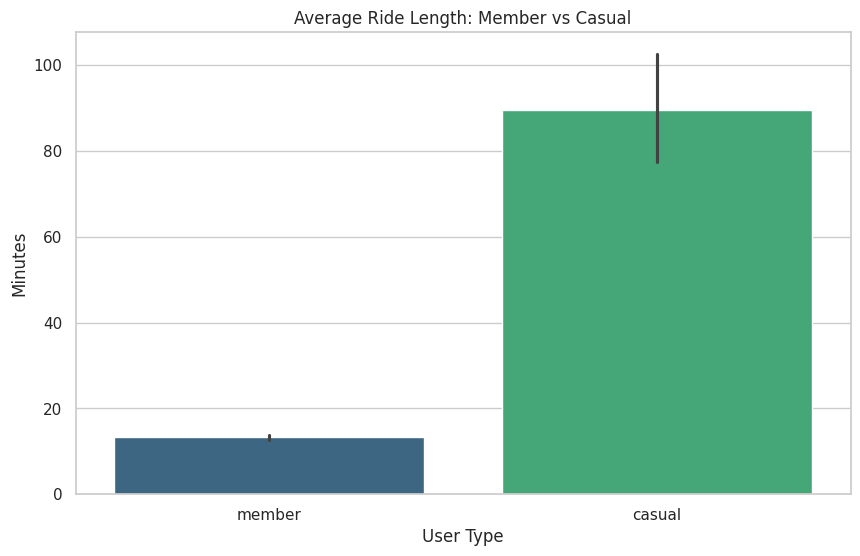

In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df,
    x='member_casual',
    y='ride_length',
    hue='member_casual',  # Add this!
    palette='viridis',
    legend=False          # Turn off the redundant legend
)

plt.title("Average Ride Length: Member vs Casual")
plt.ylabel("Minutes")
plt.xlabel("User Type")
plt.show()

Plotting  Number of rides by weekdays

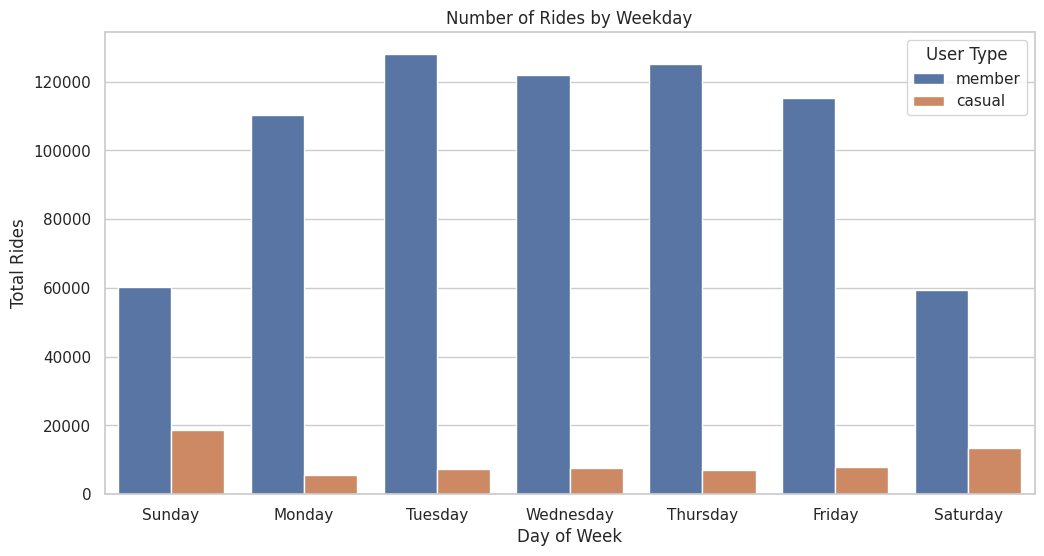

In [ ]:
day_order = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

plt.figure(figsize=(12, 6))

# 'hue' automatically splits the bars by Member/Casual
sns.countplot(data=df, x='day_of_week', hue='member_casual', order=day_order)

plt.title("Number of Rides by Weekday")
plt.ylabel("Total Rides")
plt.xlabel("Day of Week")
plt.legend(title='User Type')
plt.show()